In [6]:
!pip install pandas

/bin/bash: line 1: /home/leandro/code/ia_censo_escolar/.venv/bin/pip: cannot execute: required file not found


In [7]:
import pandas as pd

In [8]:
df = pd.read_csv('../data/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Escola_2025.csv', encoding='latin-1', sep=';')
df.head()

/tmp/ipykernel_37435/3130573893.py:1: DtypeWarning: Columns (0: NO_REGIAO_ADMINISTRATIVA, 1: CO_ORGAO_REGIONAL) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Escola_2025.csv', encoding='latin-1', sep=';')


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,IN_ESP_EXCLUSIVA_MEDIO_FIC,IN_ESP_EXCLUSIVA_MEDIO_NORMAL,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF
0,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.shape

(214192, 302)

In [10]:
df_matriculas = pd.read_csv('../data/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Matricula_2025.csv', encoding='latin-1', sep=';')
df_matriculas.head()

,NU_ANO_CENSO,CO_ENTIDADE,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AI_1,QT_MAT_FUND_AI_2,...,QT_MAT_ESP_INT,QT_MAT_ESP_CC_INT,QT_MAT_ESP_CE_INT,QT_MAT_BAS_LIBRAS,QT_MAT_ZR_URB,QT_MAT_ZR_RUR,QT_MAT_ZR_NA,QT_TRANSP_PUBLICO,QT_TRANSP_RESP_EST,QT_TRANSP_RESP_MUN
0,2025,11000023,77,0,0,0,77,77,0,14,...,0,0,0,0,76,1,0,0,0,0
1,2025,11000040,211,211,0,211,0,0,0,0,...,26,26,0,0,209,2,0,0,0,0
2,2025,11000058,1081,48,0,48,676,277,39,51,...,0,0,0,0,1078,3,0,0,0,0
3,2025,11000104,572,95,13,82,477,272,66,52,...,0,0,0,0,567,5,0,0,0,0
4,2025,11000198,978,137,49,88,644,301,51,59,...,20,20,0,0,973,5,0,0,0,0


In [11]:
print(f"Escolas distintas no df (Tabela Escola): {df['CO_ENTIDADE'].nunique()}")
print(f"Escolas distintas no df_matriculas (Tabela Matricula): {df_matriculas['CO_ENTIDADE'].nunique()}")

Escolas distintas no df (Tabela Escola): 214192
Escolas distintas no df_matriculas (Tabela Matricula): 178766


In [12]:
# Merge df_matriculas com df para obter SG_UF
df_matriculas_com_uf = df_matriculas.merge(df[['CO_ENTIDADE', 'SG_UF']], on='CO_ENTIDADE', how='left')

# Colunas de matrículas
colunas_educacao = [
    'QT_MAT_FUND_AI',      # Fundamental anos iniciais
    'QT_MAT_FUND_AF',      # Fundamental anos finais
    'QT_MAT_MED',          # Ensino médio
    'QT_MAT_PROF',         # Ensino profissionalizante
    'QT_MAT_EJA_FUND_AI',  # EJA fundamental anos iniciais
    'QT_MAT_EJA_FUND_AF',  # EJA fundamental anos finais
    'QT_MAT_EJA_MED'       # EJA ensino médio
]

# Verificar se Educação Infantil existe
if 'QT_MAT_INF' in df_matriculas.columns:
    colunas_educacao.insert(0, 'QT_MAT_INF')
elif 'QT_MAT_CRE' in df_matriculas.columns:
    colunas_educacao.insert(0, 'QT_MAT_CRE')

# Agrupar por estado e somar
alunos_por_estado = df_matriculas_com_uf.groupby('SG_UF')[colunas_educacao].sum()

# Renomear colunas para nomes mais legíveis
alunos_por_estado.columns = [
    'Educação Infantil' if 'INF' in col or 'CRE' in col else col.replace('QT_MAT_', '').replace('_', ' ').title() 
    for col in alunos_por_estado.columns
]

# Adicionar coluna de total
alunos_por_estado['Total'] = alunos_por_estado.sum(axis=1)

alunos_por_estado

,Educação Infantil,Fund Ai,Fund Af,Med,Prof,Eja Fund Ai,Eja Fund Af,Eja Med,Total
SG_UF,,,,,,,,,
AC,39559,81006,61486,37266,23252,7390,5524,7522,263005
AL,157135,239684,190896,122787,82406,44593,22963,23342,883806
AM,178941,384463,296226,191839,40640,12901,22287,20754,1148051
AP,29581,75374,53405,33626,11186,2154,5459,8311,219096
BA,582760,996376,794612,479086,211101,203443,103186,118745,3489309
CE,431562,640513,489111,356773,157127,43163,51175,51559,2220983
DF,107953,200751,153622,105044,47130,3191,8615,10630,636936
ES,181482,286875,215851,127580,70383,3268,11585,16189,913213
GO,283530,500276,375446,238959,197542,4340,12635,29596,1642324


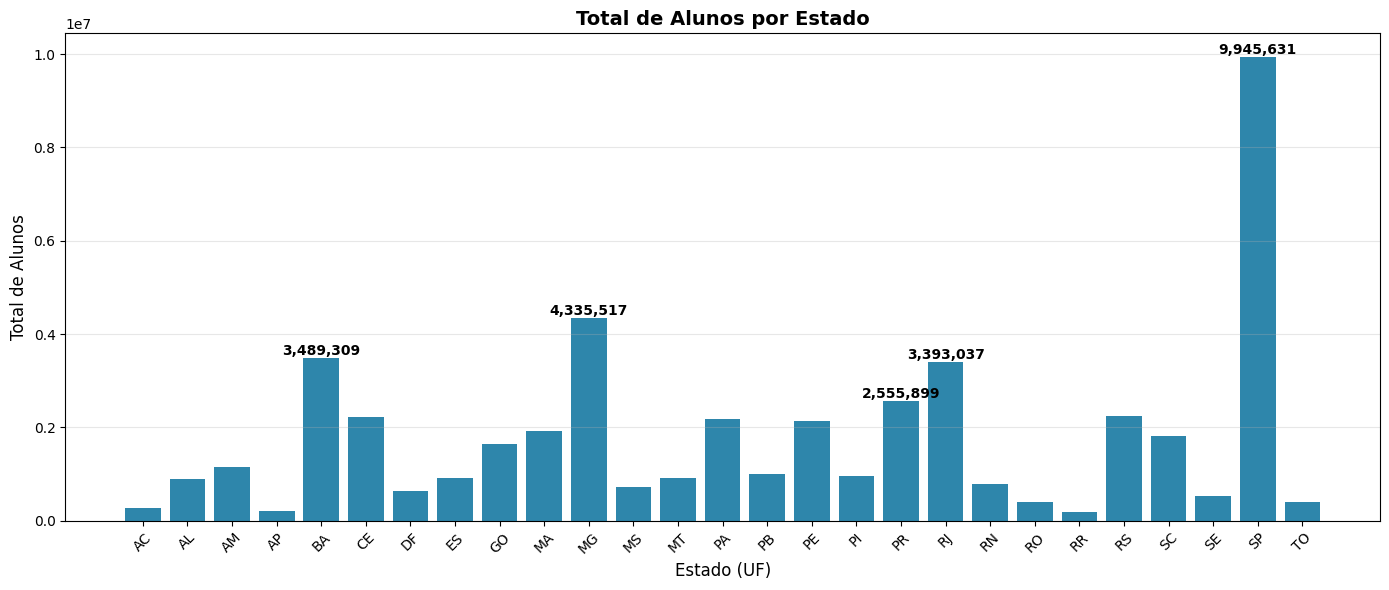

In [13]:
import matplotlib.pyplot as plt

# Ordenar pela sigla do estado
alunos_por_estado_sorted = alunos_por_estado.sort_index()

# Criar gráfico
plt.figure(figsize=(14, 6))
bars = plt.bar(alunos_por_estado_sorted.index, alunos_por_estado_sorted['Total'], color='#2E86AB')

plt.title('Total de Alunos por Estado', fontsize=14, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Total de Alunos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

# Adicionar labels para os 5 estados com mais alunos
top_5_estados = alunos_por_estado_sorted.nlargest(5, 'Total')
for i, (estado, total) in enumerate(top_5_estados['Total'].items()):
    # Encontrar a posição da barra correspondente
    idx = alunos_por_estado_sorted.index.get_loc(estado)
    plt.text(idx, total, f'{int(total):,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.show()

In [14]:
# Dados de população por estado (IBGE 2025)
populacao_por_estado = {
    'SP': 46081801,
    'MG': 21393441,
    'RJ': 17223547,
    'BA': 14870907,
    'PR': 11890517,
    'RS': 11233263,
    'PE': 9562007,
    'CE': 9268836,
    'PA': 8711196,
    'SC': 8187029,
    'GO': 7423629,
    'MA': 7018211,
    'AM': 4321616,
    'PB': 4164468,
    'ES': 4126854,
    'MT': 3893659,
    'RN': 3455236,
    'PI': 3384547,
    'AL': 3220848,
    'DF': 2996899,
    'MS': 2924631,
    'SE': 2299425,
    'RO': 1751950,
    'TO': 1586859,
    'AC': 884372,
    'AP': 806517,
    'RR': 738772
}

# Criar DataFrame com dados de população
df_populacao = pd.DataFrame(list(populacao_por_estado.items()), columns=['SG_UF', 'Populacao'])
df_populacao = df_populacao.set_index('SG_UF')

# Calcular porcentagem de alunos em relação à população do estado (alunos / população * 100)
df_completo = alunos_por_estado.join(df_populacao)
df_completo['Porcentagem_Alunos'] = (df_completo['Total'] / df_completo['Populacao']) * 100

# Ordenar por população
df_completo = df_completo.sort_values('Populacao', ascending=True)

df_completo

,Educação Infantil,Fund Ai,Fund Af,Med,Prof,Eja Fund Ai,Eja Fund Af,Eja Med,Total,Populacao,Porcentagem_Alunos
SG_UF,,,,,,,,,,,
RR,34570,68093,46757,25921,9285,926,1430,4011,190993,738772,25.852766
AP,29581,75374,53405,33626,11186,2154,5459,8311,219096,806517,27.165701
AC,39559,81006,61486,37266,23252,7390,5524,7522,263005,884372,29.739182
TO,79778,119577,97352,69916,17209,3234,2829,4370,394265,1586859,24.845623
RO,62782,124783,97665,72685,20745,1077,4487,7469,391693,1751950,22.357544
SE,95720,163936,133932,84241,26938,11600,13580,7950,537897,2299425,23.392674
MS,145376,233689,162857,101886,69997,3959,5532,6594,729890,2924631,24.956653
DF,107953,200751,153622,105044,47130,3191,8615,10630,636936,2996899,21.253169
AL,157135,239684,190896,122787,82406,44593,22963,23342,883806,3220848,27.440165


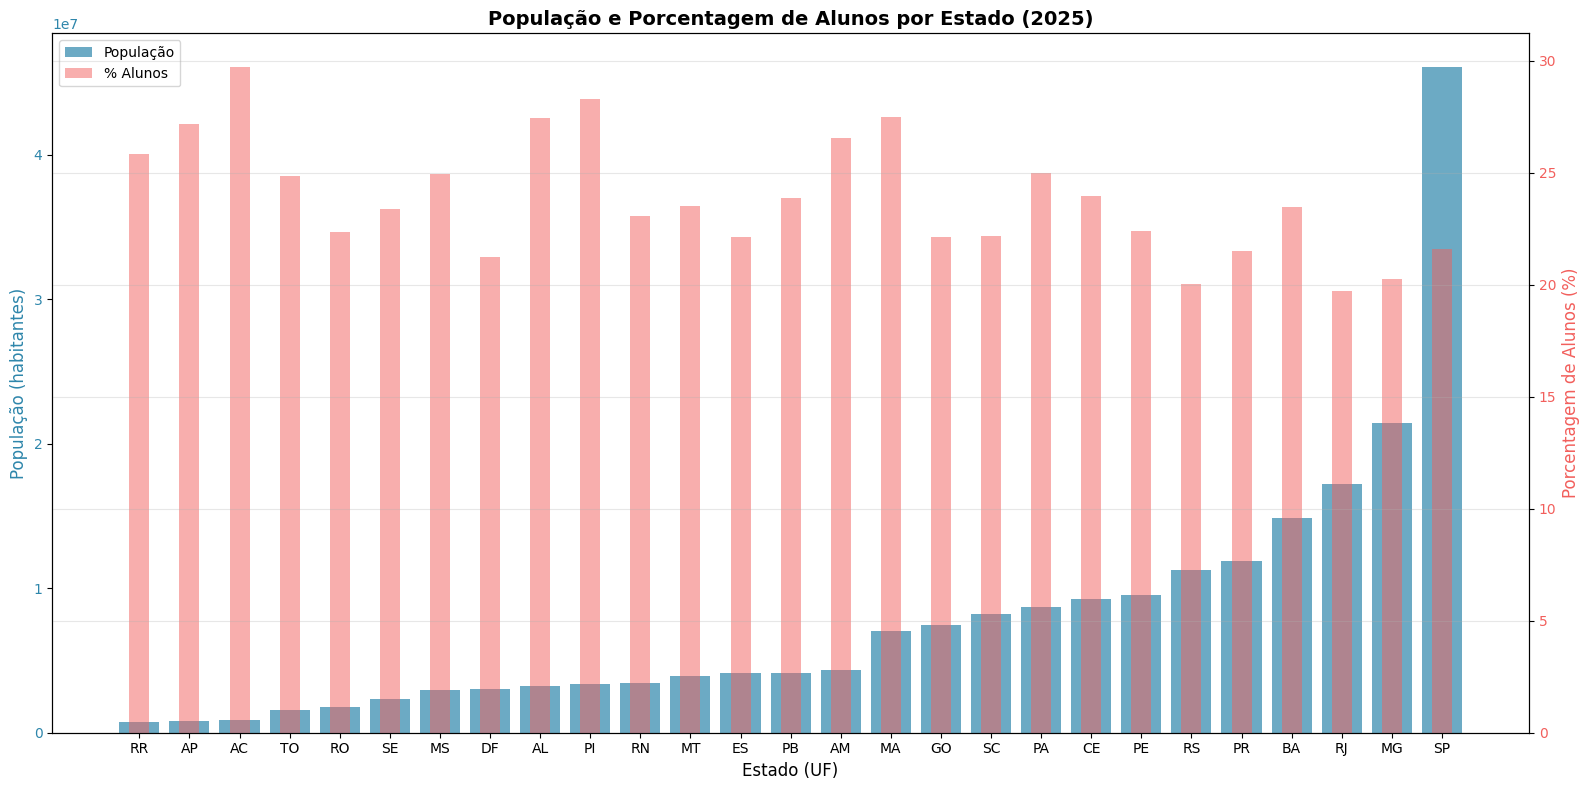

In [15]:
# Criar gráfico com população e porcentagem de alunos
fig, ax1 = plt.subplots(figsize=(16, 8))

# Gráfico de barras para população (eixo Y esquerdo)
bars1 = ax1.bar(df_completo.index, df_completo['Populacao'], color='#2E86AB', alpha=0.7, label='População')
ax1.set_xlabel('Estado (UF)', fontsize=12)
ax1.set_ylabel('População (habitantes)', fontsize=12, color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_title('População e Porcentagem de Alunos por Estado (2025)', fontsize=14, fontweight='bold')

# Eixo Y direito para porcentagem de alunos
ax2 = ax1.twinx()
bars2 = ax2.bar(df_completo.index, df_completo['Porcentagem_Alunos'], color='#F25F5C', alpha=0.5, width=0.4, label='% Alunos')
ax2.set_ylabel('Porcentagem de Alunos (%)', fontsize=12, color='#F25F5C')
ax2.tick_params(axis='y', labelcolor='#F25F5C')

# Rotacionar labels do eixo X
plt.xticks(rotation=45, ha='right')

# Adicionar legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Matrículas por cidade

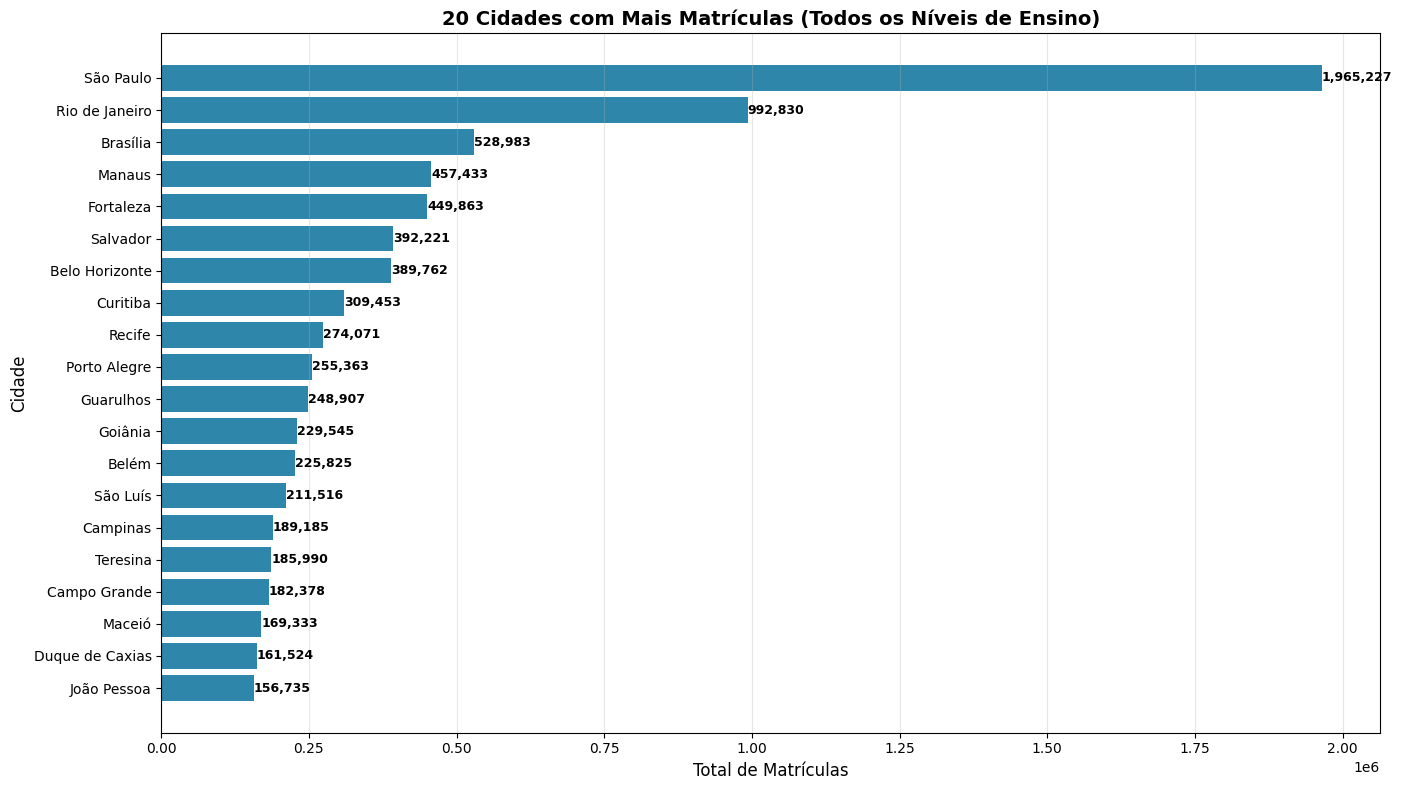

In [16]:
# Merge df_matriculas com df para obter NO_MUNICIPIO e CO_MUNICIPIO
df_matriculas_com_municipio = df_matriculas.merge(df[['CO_ENTIDADE', 'NO_MUNICIPIO', 'CO_MUNICIPIO']], on='CO_ENTIDADE', how='left')

# Colunas de matrículas por nível
colunas_matriculas = [
    'QT_MAT_FUND_AI',      # Fundamental anos iniciais
    'QT_MAT_FUND_AF',      # Fundamental anos finais
    'QT_MAT_MED',          # Ensino médio
    'QT_MAT_PROF',         # Ensino profissionalizante
    'QT_MAT_EJA_FUND_AI',  # EJA fundamental anos iniciais
    'QT_MAT_EJA_FUND_AF',  # EJA fundamental anos finais
    'QT_MAT_EJA_MED'       # EJA ensino médio
]

# Agrupar por município e somar as matrículas
alunos_por_municipio = df_matriculas_com_municipio.groupby(['NO_MUNICIPIO', 'CO_MUNICIPIO'])[colunas_matriculas].sum()

# Calcular o total de matrículas por município
alunos_por_municipio['Total'] = alunos_por_municipio.sum(axis=1)

# Obter as 20 cidades com mais matrículas
top_20_cidades = alunos_por_municipio.nlargest(20, 'Total').reset_index()

# Criar gráfico
plt.figure(figsize=(14, 8))
bars = plt.barh(top_20_cidades['NO_MUNICIPIO'], top_20_cidades['Total'], color='#2E86AB')

plt.title('20 Cidades com Mais Matrículas (Todos os Níveis de Ensino)', fontsize=14, fontweight='bold')
plt.xlabel('Total de Matrículas', fontsize=12)
plt.ylabel('Cidade', fontsize=12)
plt.gca().invert_yaxis()  # Mostrar a maior barra no topo
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)

# Adicionar labels com o valor total
for i, (cidade, total) in enumerate(zip(top_20_cidades['NO_MUNICIPIO'], top_20_cidades['Total'])):
    plt.text(total, i, f'{int(total):,}', va='center', ha='left', fontsize=9, fontweight='bold')

plt.show()